In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [254]:
df = pd.read_csv('../data/raw_data.csv')

# Exploratory Data Analysis (EDA)

## Data Overview

In [255]:
df.shape

(7043, 21)

In [256]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [257]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [258]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Quality Audit

In [259]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [260]:
df = df.drop('customerID', axis=1)

In [261]:
df.duplicated().sum()

np.int64(22)

In [262]:
cat_features = df.select_dtypes(include='str').columns.tolist()
cat_features.append('SeniorCitizen')
cat_features.remove('Churn')

In [263]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0:"No", 1:"Yes"})

In [264]:
for i in cat_features:
    print(df[i].value_counts(), '\n')

gender
Male      3555
Female    3488
Name: count, dtype: int64 

Partner
No     3641
Yes    3402
Name: count, dtype: int64 

Dependents
No     4933
Yes    2110
Name: count, dtype: int64 

PhoneService
Yes    6361
No      682
Name: count, dtype: int64 

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64 

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64 

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64 

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64 

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64 

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64 

StreamingTV
No       

In [265]:
for i in cat_features:
    print(f'Unique values of {i}: {df[i].nunique()}', '', sep='\n')

Unique values of gender: 2

Unique values of Partner: 2

Unique values of Dependents: 2

Unique values of PhoneService: 2

Unique values of MultipleLines: 3

Unique values of InternetService: 3

Unique values of OnlineSecurity: 3

Unique values of OnlineBackup: 3

Unique values of DeviceProtection: 3

Unique values of TechSupport: 3

Unique values of StreamingTV: 3

Unique values of StreamingMovies: 3

Unique values of Contract: 3

Unique values of PaperlessBilling: 2

Unique values of PaymentMethod: 4

Unique values of TotalCharges: 6531

Unique values of SeniorCitizen: 2



In [266]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
cat_features.remove('TotalCharges')
df['TotalCharges'].isna().sum()

np.int64(11)

In [267]:
df[df['TotalCharges'].isna()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [268]:
if df[df['TotalCharges'].isna()].equals(df[df['tenure'] == 0]):
    print('Equal')
else:
    print('Not equal')

Equal


In [269]:
df[df['TotalCharges'].isna()].index.tolist()

[488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754]

In [270]:
df = df.drop(labels=df[df['TotalCharges'].isna()].index, axis=0)

In [271]:

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

## Univariate Analysis

### Numerical Features

In [272]:
sns.set_palette('crest')

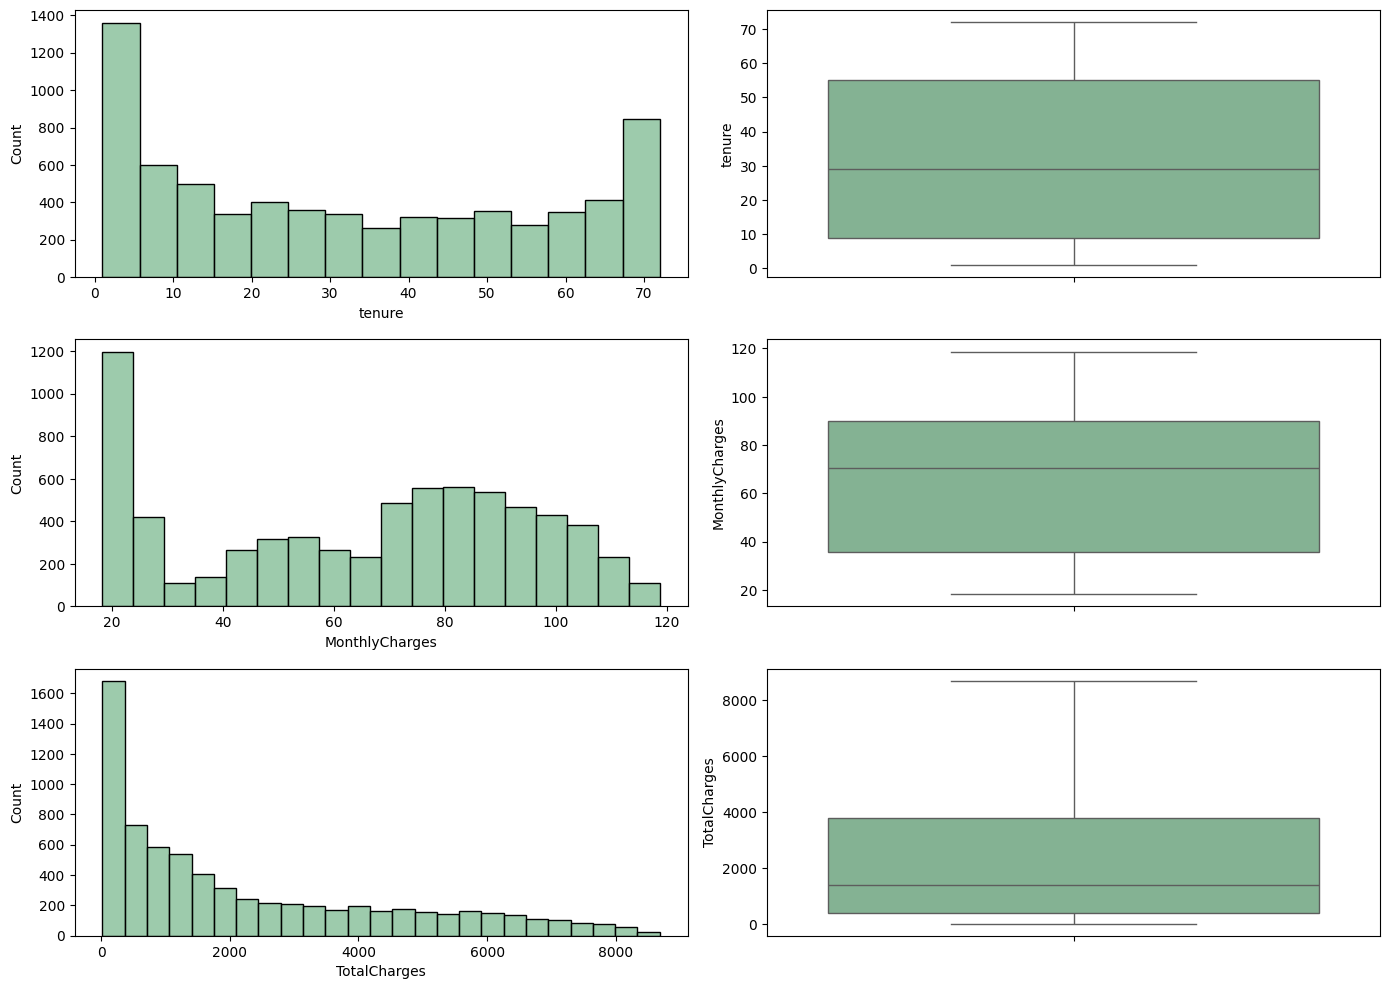

In [273]:
fig, axes = plt.subplots(3, 2, figsize=[14,10])

for (ind, col) in enumerate(num_features):
    sns.histplot(df[col], ax=axes[ind][0])
    sns.boxplot(df[col], ax=axes[ind][1])

plt.tight_layout()
plt.show()

**Key Insights from Numerical Features:**

*   **Tenure:** Distribution is bimodal with major peaks at 1 and 72 months. The high volume of 1-month users indicates potential early churn issues, while the 72-month peak suggests data capping for long-term loyal customers.
*   **Monthly Charges:** Shows two distinct segments: a massive "budget" peak at ~20 and a broader "high-tier" segment between 70-100. There is a noticeable lack of mid-range customers (30-50).
*   **Total Charges:** Heavily right-skewed (long tail), which is expected as it correlates with tenure. Most customers have low cumulative spending.
*   **Outliers:** Boxplots confirm there are no significant outliers in numerical features, meaning the data is relatively clean.

### Categorical Features

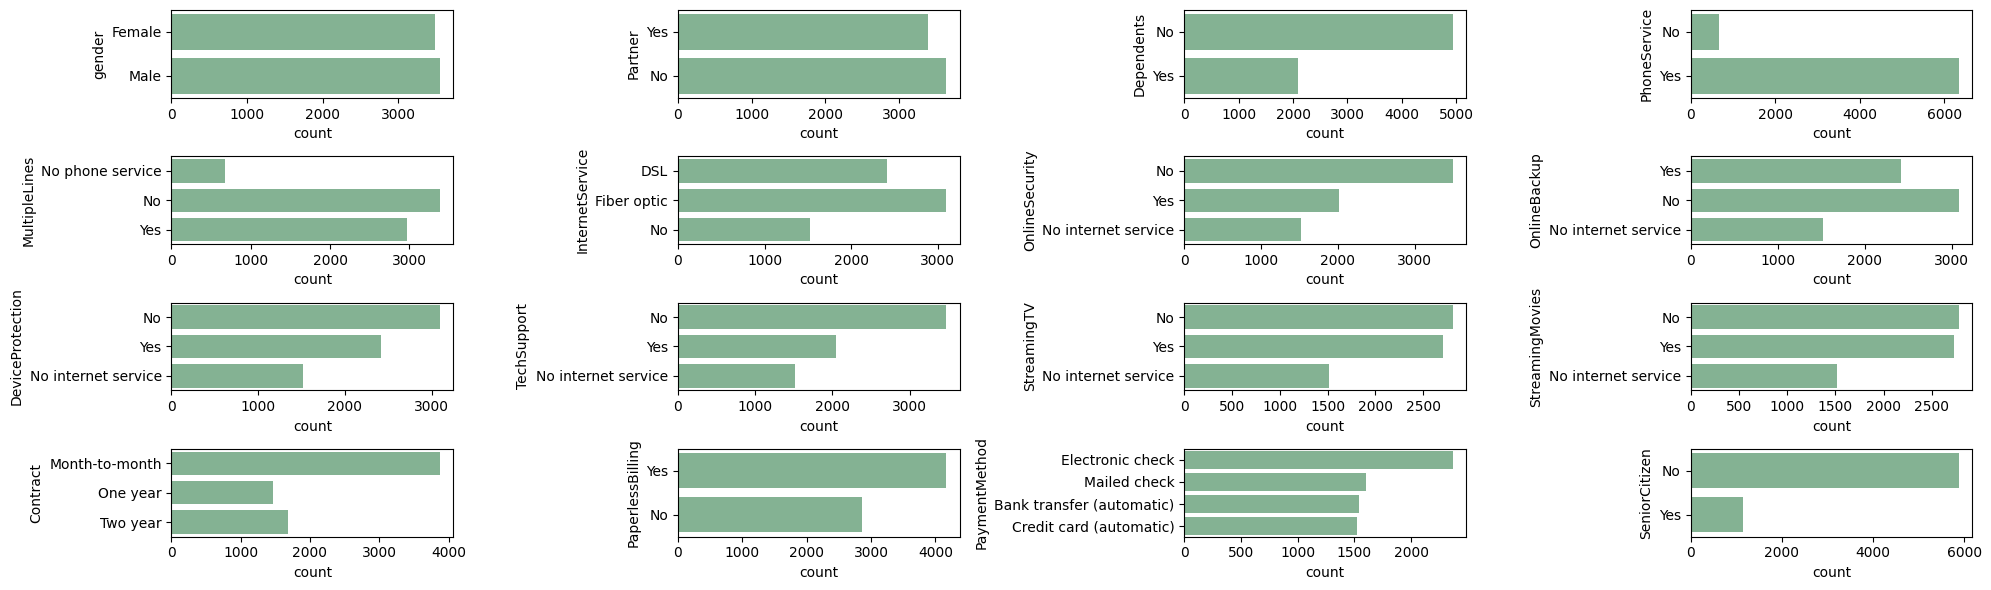

In [274]:
fig, axes = plt.subplots(4, 4, figsize=[20,6])
axes = axes.flatten()

for (ind, col) in enumerate(cat_features):
    sns.countplot(df[col], ax=axes[ind])

plt.tight_layout()
plt.show()

**Key Insights from Categorical Features:**

*   **Redundancy:** Several features (OnlineSecurity, TechSupport, etc.) contain a "No internet service" category, which is entirely dependent on the `InternetService` column. Simplifying these to a binary "Yes/No" could reduce model complexity.
*   **Contract Type:** The majority of customers are on a "Month-to-month" plan, which is typically the primary driver for churn.
*   **Service Imbalance:** `PhoneService` has very low variance (most customers have it), potentially offering limited predictive power.
*   **Payment Methods:** "Electronic check" is the most frequent payment method and deserves further investigation regarding its correlation with churn.

**Encoding Strategy:** I will simplify "No internet service" to "No" across relevant columns and apply One-Hot Encoding with `drop='first'` to handle categorical variables without introducing multicollinearity.

## Target Analysis

In [275]:
print(df['Churn'].map({"No":0, "Yes": 1}).sum() / df['Churn'].count())

0.26578498293515357


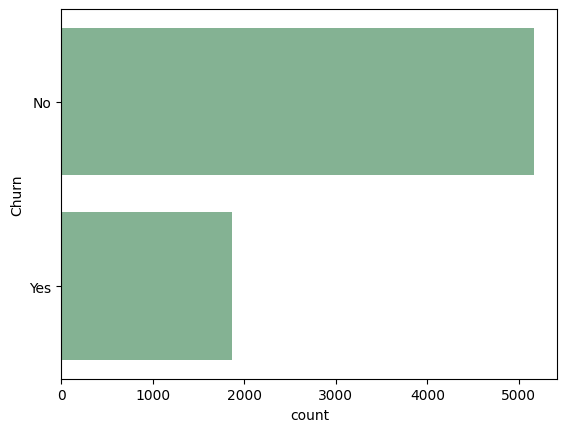

In [276]:
sns.countplot(df['Churn'])
plt.show()

**Target Variable Analysis (Churn)**:

*   **Churn Rate:** Approximately 26.6% of customers have left the company.
*   **Class Imbalance:** We observe a ~3:1 ratio between the majority ("No") and minority ("Yes") classes. This indicates a moderate class imbalance.
*   **Baseline Accuracy:** A naive model predicting "No" for everyone would achieve ~73.4% accuracy. My goal is to develop a model that significantly outperforms this baseline.
*   **Metric Selection:** Due to the imbalance, Accuracy will be a misleading metric. I will prioritize F1-Score, Precision-Recall, and ROC-AUC to ensure the model effectively identifies churners without excessive false positives.

## Multivariate Analysis

### Numerical features

In [277]:
sns.set_palette('deep')

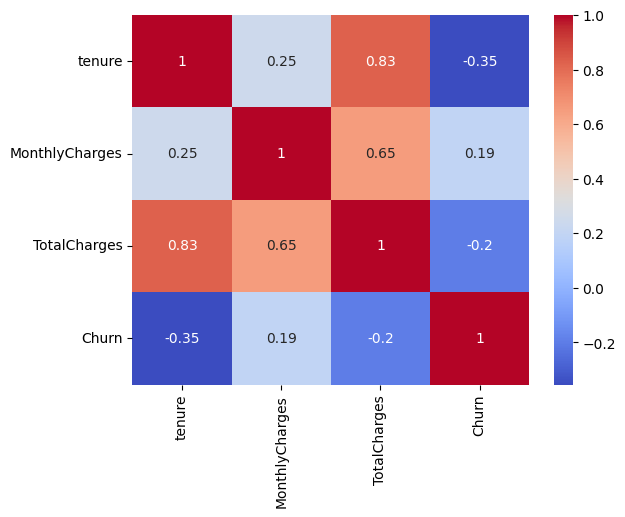

In [278]:
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'No':0, 'Yes':1})

sns.heatmap(df_corr[[*num_features, 'Churn']].corr(), annot=True, cmap='coolwarm')

plt.show()

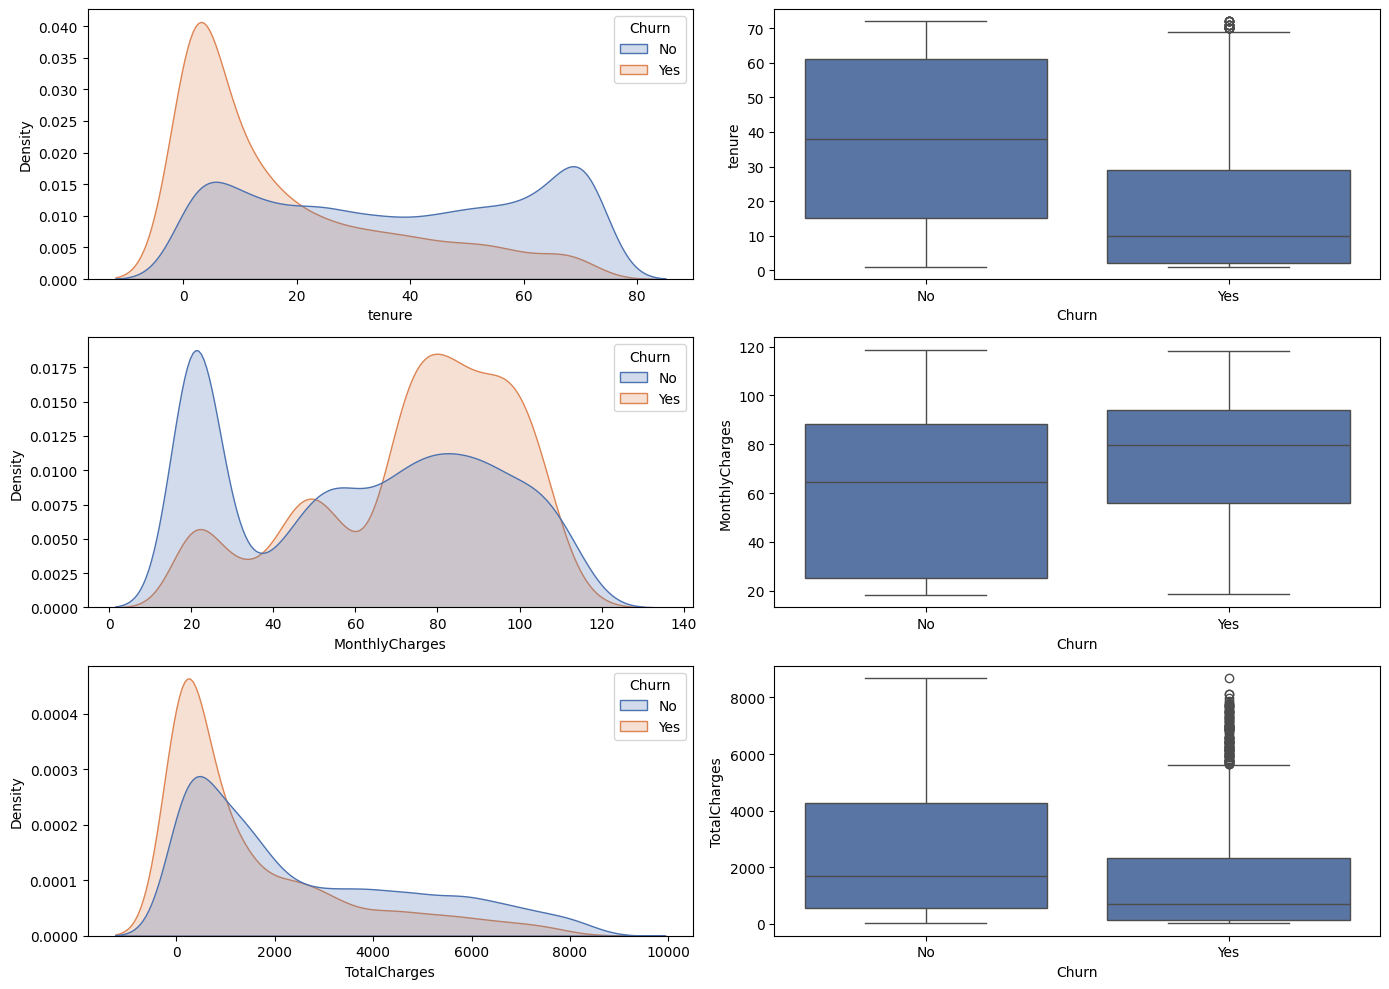

In [279]:
fig, axes = plt.subplots(3, 2, figsize=[14,10])

for (ind, col) in enumerate(num_features):
    sns.kdeplot(data=df, x=col, ax=axes[ind][0], hue='Churn', fill=True, common_norm=False)
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[ind][1])

plt.tight_layout()
plt.show()

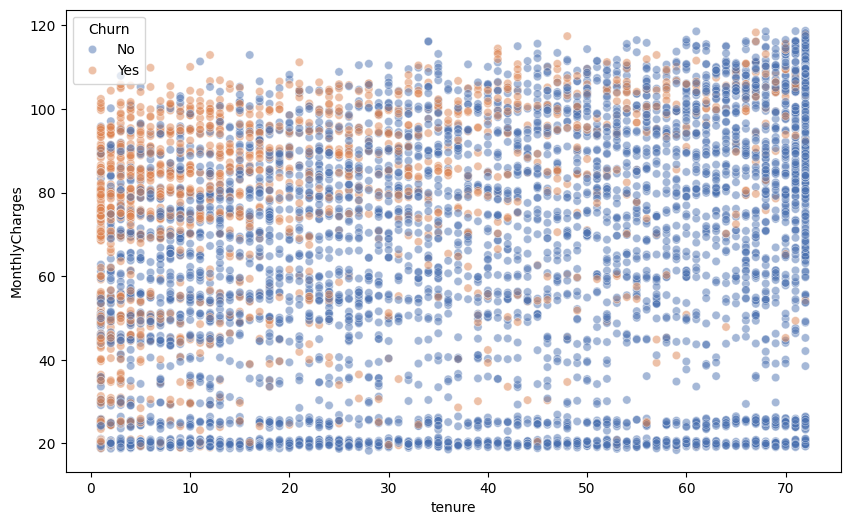

In [280]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.5)
plt.show()

**Key Insights from Multivariate Numerical Analysis:**

1.  **Multicollinearity Alert:** A high correlation (0.83) is observed between `tenure` and `TotalCharges`. To avoid redundancy and potential issues with linear models, I may consider dropping one of these features during the modeling phase.
2.  **Churn Patterns:**
    *   **Tenure:** The churned population is heavily skewed towards new customers (low tenure). Loyal customers with tenure > 60 months rarely leave.
    *   **Monthly Charges:** Churn probability increases significantly for customers with high monthly bills (above $70), suggesting price sensitivity in the high-tier segment.
3.  **Risk Zone:** The interaction analysis shows that customers with high monthly charges within their first 12 months are at the highest risk of churn.

**Conclusion:** Tenure and MonthlyCharges appear to be the most influential numerical predictors for the model.

### Categorical features

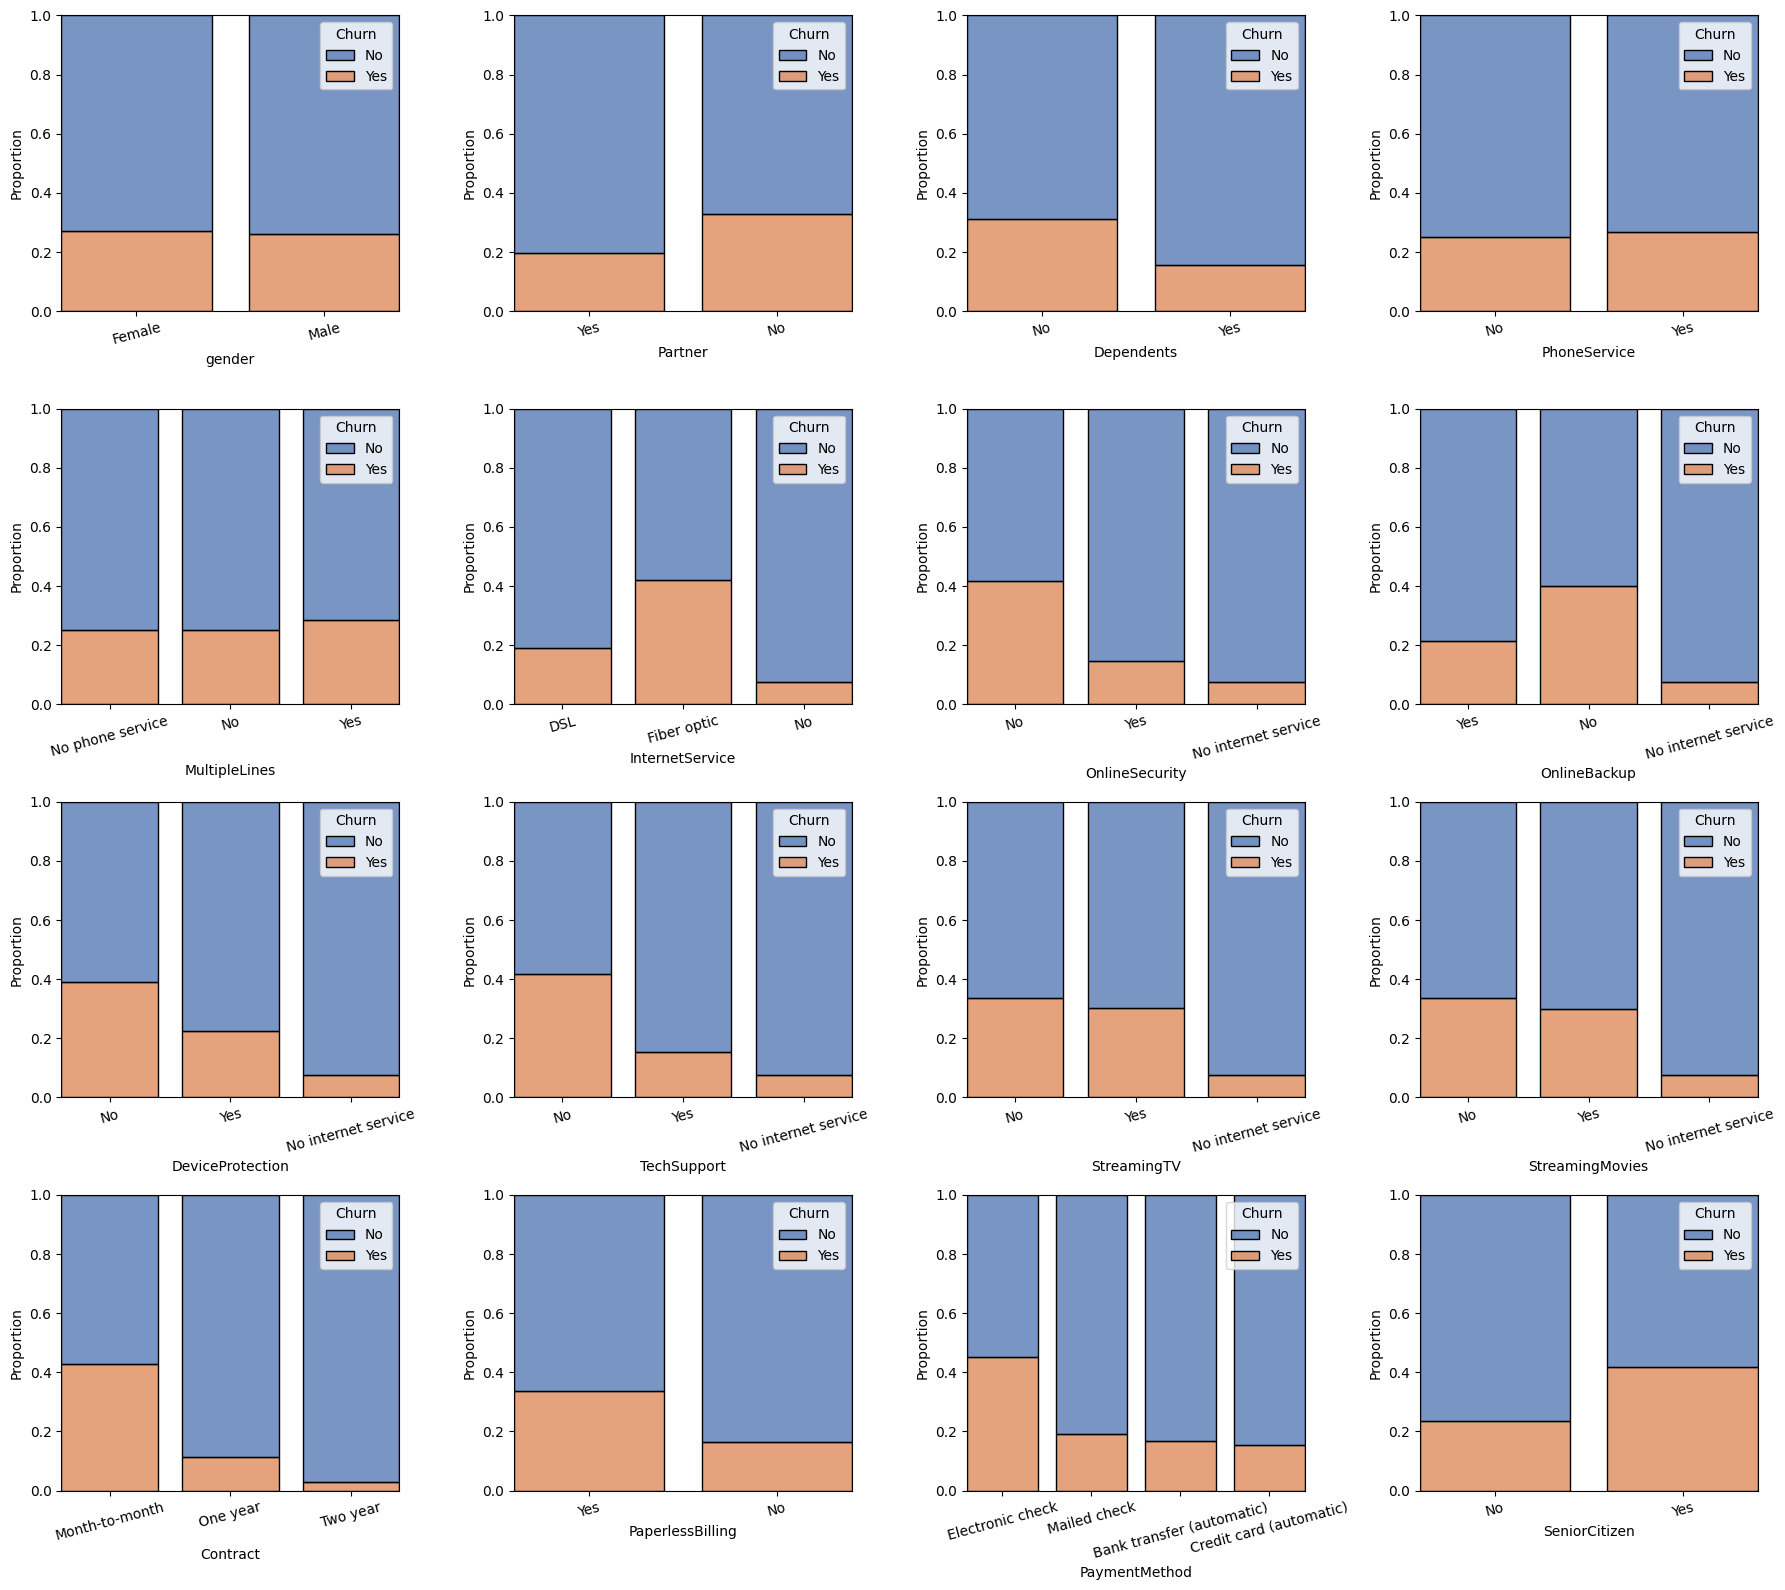

In [281]:
fig, axes = plt.subplots(4, 4, figsize=[18, 16])
axes = axes.flatten()

for (ind, col) in enumerate(cat_features):
    sns.histplot(data=df, x=col, ax=axes[ind], shrink=0.8, hue='Churn', multiple='fill', stat='proportion')
    axes[ind].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Key Insights from Multivariate Categorical Analysis**:

1.  **High-Risk Segments:**
    *   **Contract:** Month-to-month customers show a significantly higher churn rate compared to long-term contracts.
    *   **Internet Service:** Fiber optic users are much more likely to churn than DSL users, suggesting potential issues with pricing or service quality in that segment.
    *   **Payment Method:** Users paying via Electronic check exhibit the highest churn probability.

2.  **Service Stickiness:**
    *   Customers without additional services like OnlineSecurity or TechSupport are much more prone to leaving. These services appear to act as retention drivers.

3.  **Low Predictive Power:**
    *   Gender and PhoneService show nearly identical churn distributions across all categories. These features likely contribute very little to the model's predictive ability and could be candidates for removal during feature selection.

**Conclusion:** The model should heavily weight Contract type, Internet Service, and the presence of security-related add-ons.